In [4]:
import os
import sys
import numpy as np
import time
import scipy
import matplotlib.pyplot as plt
import time

In [5]:
current_dir =  os.getcwd()
parent_dir = os.path.abspath(os.path.join(current_dir, os.pardir))
sys.path.append(parent_dir)

In [8]:
#frank2d
from frank2d.frank2d import Frank2D
from frank2d.constants import rad_to_arcsec, deg_to_rad
from frank2d.geometry import Geometry

In [10]:
import numpy as np
from scipy.stats import binned_statistic_2d

class Gridding(object):
    def __init__(self, N, Rmax, FT, Geometry):
        self._N = N
        self._Rmax = Rmax
        self._FT =  FT
        self._Geometry = Geometry

    def run(self, u, v, Vis, Weights, type = 'weighted', shift = False, hermitian = True):  
        
        u_, v_, Vis_ = u, v, Vis

        if self._Geometry._deproject:
            print("Deprojecting...")
            u_, v_, Vis_ = self._Geometry.apply_correction(u, v, Vis)
        
        # Calculating bin edges.
        bin_centers = self.edges_centers(self._FT._u_shifted)[0]
        bin_edges_u = self.edges_centers(self._FT._u_shifted)[1]
        bin_edges_v = self.edges_centers(self._FT._v_shifted)[1]


        if type == 'weighted':
            u_gridded, v_gridded, vis_gridded, weights_gridded = self.weighted_gridding(u_, v_, Vis_, Weights,
                                                                                        bin_centers, bin_edges_u, bin_edges_v,
                                                                                        shift = shift, hermitian = hermitian)

            return u_gridded, v_gridded, vis_gridded, weights_gridded

    def edges_centers(self, freq):
        correction = (freq[1] - freq[0])/2
        
        # Creating the grid with shifted scheme.
        bin_centers = freq
        bin_edges_=  bin_centers - correction
        bin_edges = np.concatenate((bin_edges_, [bin_edges_[-1] + 2*correction]))
        return bin_centers, bin_edges
    
    def weighted_gridding(self, u, v, Vis, Weights, centers, edges_u, edges_v, shift = False, hermitian = True):
        # Calculating values in grid
        vis_gridded_matrix_before, _, _, _ = binned_statistic_2d(u, v, Vis, 'sum', bins=[edges_u, edges_v], expand_binnumbers = False)
        vis_weights_sum_bin, _, _, _ = binned_statistic_2d(u, v, Vis*Weights, 'sum', bins=[edges_u, edges_v], expand_binnumbers = False)
        weights_gridded_matrix, _, _, _ = binned_statistic_2d(u, v, Weights, 'sum', bins=[edges_u, edges_v], expand_binnumbers = False)

        vis_gridded_matrix =  vis_weights_sum_bin/weights_gridded_matrix

        print("NaN weights: ", np.where(weights_gridded_matrix == 0))
        print("NaN vis: ", np.where(np.isnan(vis_gridded_matrix)))

        plt.imshow(np.log(np.abs(vis_gridded_matrix_before)), cmap='viridis')
        plt.title("Abs Vis before")
        plt.colorbar()
        plt.show()

        plt.imshow(np.log(np.abs(vis_weights_sum_bin)), cmap='viridis')
        plt.title("Abs Vis*Weights")
        plt.colorbar()
        plt.show()

        plt.imshow(np.log(weights_gridded_matrix), cmap='viridis')
        plt.title("Weights")
        plt.colorbar()
        plt.show()

        plt.imshow(np.log(np.abs(vis_gridded_matrix)), cmap='viridis')
        plt.title("Abs Vis after")
        plt.colorbar()
        plt.show()


        # Change Nans by 0 in vis.
        vis_gridded = np.nan_to_num(vis_gridded_matrix, nan=0)
        weights_gridded = np.nan_to_num(weights_gridded_matrix, nan=0)

        # Imposing hermitian conjugate property.
        if hermitian:
            vis_gridded, weights_gridded = self.enforce_hermitian_symmetry(vis_gridded, weights_gridded)

        if shift:
            # Shifting the grid, i.e. spatial frequencies centered in 0.
            u_gridded, v_gridded, vis_gridded, weights_gridded = self.shiftting(centers, vis_gridded, weights_gridded)
        else:
            # Unshifted grid.
            u_gridded, v_gridded = self._FT._Un, self._FT._Vn # unshifted by default.
            vis_gridded = np.fft.fftshift(vis_gridded).flatten()
            weights_gridded = np.fft.fftshift(weights_gridded).flatten()

        # Change Nans by 0 in vis again.
        vis_gridded = np.nan_to_num(vis_gridded, nan=0)
        weights_gridded = np.nan_to_num(weights_gridded, nan=0)
            
        return u_gridded, v_gridded, vis_gridded, weights_gridded

    def enforce_hermitian_symmetry(self, vis, wts):
        vis = np.fft.fftshift(vis)
        wts = np.fft.fftshift(wts)
        nx, ny = vis.shape
        cx, cy = (nx // 2), (ny // 2)

        print("Enforcing Hermitian symmetry...")
        for x in range(nx):  
            for y in range(ny):
                x_sym = (-x) % nx
                y_sym = (-y) % ny

                v_xy = vis[y, x]
                v_neg_xy = vis[y_sym, x_sym]

                w_xy = wts[y, x]
                w_neg_xy = wts[y_sym, x_sym]

                if w_xy > 0 or w_neg_xy > 0:    
                    w_tot = w_xy + w_neg_xy
                    if w_tot > 0:
                        val = (np.conj(v_neg_xy) * w_neg_xy + v_xy * w_xy) / w_tot
                        vis[y, x] = val
                        vis[y_sym, x_sym] = np.conj(val)

                        wts[y, x] = w_tot
                        wts[y_sym, x_sym] = w_tot

        vis = np.fft.ifftshift(vis)
        wts = np.fft.ifftshift(wts)
        return vis, wts

    def shiftting(self, freqs, vis_matrix, weights_matrix):
        vis_gridded = vis_matrix.flatten()
        weights_gridded = weights_matrix.flatten()
        u_, v_ = np.meshgrid(freqs, freqs, indexing='ij') 
        u_gridded, v_gridded = u_.reshape(-1), v_.reshape(-1)
        return u_gridded, v_gridded, vis_gridded, weights_gridded

In [11]:
AS209 = {'inc': 34.97, 'pa': 85.76, 'dra':1.9e-3, 'ddec':-2.5e-3, 'rout': 1.2*2, 'disk_name': 'AS209'}
IMLup = {'inc': 47.5, 'pa': 144.5, 'dra':-1.5e-3, 'ddec':1e-3, 'rout': 1.71*2, 'disk_name': 'IMLup'}
Elias27 = {'inc': 56.2, 'pa': 118.8, 'dra':-5e-3, 'ddec':-8e-3, 'rout': 1.88*2, 'disk_name': 'Elias27'}
HD163296 = {'inc':46.7, 'pa':133.33, 'dra':-2.8e-3, 'ddec':7.7e-3, 'rout':1.7*2, 'disk_name': 'HD163296' }
Elias24 = {'inc': 29, 'pa': 45.7, 'dra':110.8e-3, 'ddec':-386.8e-3, 'rout': 1.03*2, 'disk_name': 'Elias24'}

In [21]:
data = AS209

dir = "/Users/mariajmelladot/Desktop/Frank2D/data/uvtables/"
disk_name = data['disk_name']
data_file = dir +"uvtable_" + disk_name + "_continuum.npz"

# Huang 2018 
inc = data['inc']
pa = data['pa']
dra = data['dra']
ddec = data['ddec']
r_out = data['rout']

In [48]:
# Frank Parameters
N = 200
 # load data
file = np.load(data_file)
u, v, Re, Im, Weights = file['u'], file['v'], file['Re'], file['Im'], file['w']
Vis = Re + Im*1j

/var/folders/ng/vs__trg57hl3mtgq5kgkzj4h0000gn/T/ipykernel_10233/1064690447.py:47: RuntimeWarning: invalid value encountered in divide
  vis_gridded_matrix =  vis_weights_sum_bin/weights_gridded_matrix
/var/folders/ng/vs__trg57hl3mtgq5kgkzj4h0000gn/T/ipykernel_10233/1064690447.py:52: RuntimeWarning: divide by zero encountered in log
  plt.imshow(np.log(np.abs(vis_gridded_matrix_before)), cmap='viridis')


NaN weights:  (array([  0,   0,   0, ..., 199, 199, 199]), array([  0,   1,   2, ..., 197, 198, 199]))
NaN vis:  (array([  0,   0,   0, ..., 199, 199, 199]), array([  0,   1,   2, ..., 197, 198, 199]))


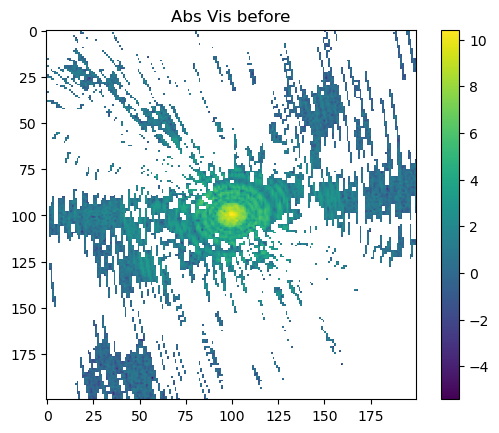

/var/folders/ng/vs__trg57hl3mtgq5kgkzj4h0000gn/T/ipykernel_10233/1064690447.py:57: RuntimeWarning: divide by zero encountered in log
  plt.imshow(np.log(np.abs(vis_weights_sum_bin)), cmap='viridis')


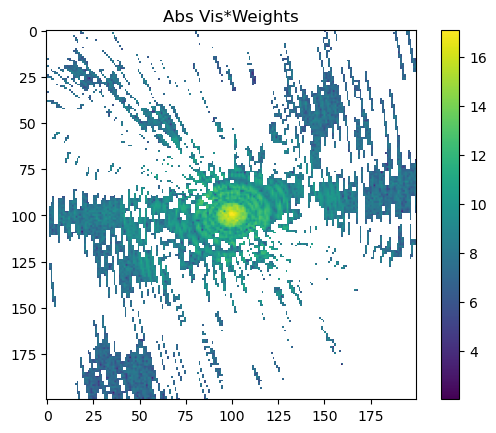

/var/folders/ng/vs__trg57hl3mtgq5kgkzj4h0000gn/T/ipykernel_10233/1064690447.py:62: RuntimeWarning: divide by zero encountered in log
  plt.imshow(np.log(weights_gridded_matrix), cmap='viridis')


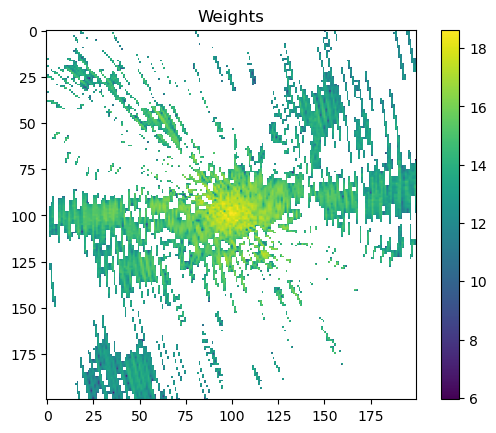

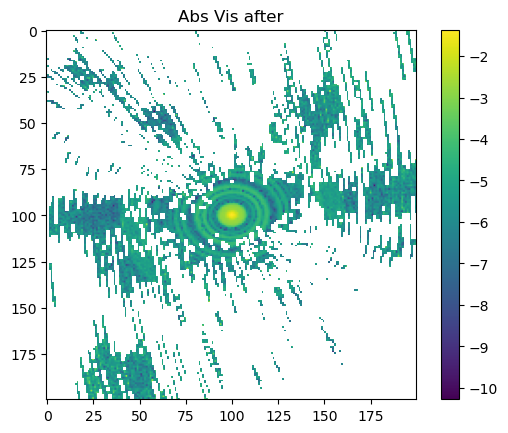

Enforcing Hermitian symmetry...


In [49]:
geom = Geometry(inc, pa, dra, ddec)
frank2d = Frank2D(N, r_out, geom)
grid = Gridding(frank2d._N, frank2d._Rmax, frank2d._FT, frank2d._Geometry)
u_gridded, v_gridded, vis_gridded, weights_gridded = grid.run(u, v, Vis, Weights,
                                                              hermitian = True)

/var/folders/ng/vs__trg57hl3mtgq5kgkzj4h0000gn/T/ipykernel_10233/3435422879.py:8: RuntimeWarning: divide by zero encountered in log
  np.log(np.abs(vis_shifted)),


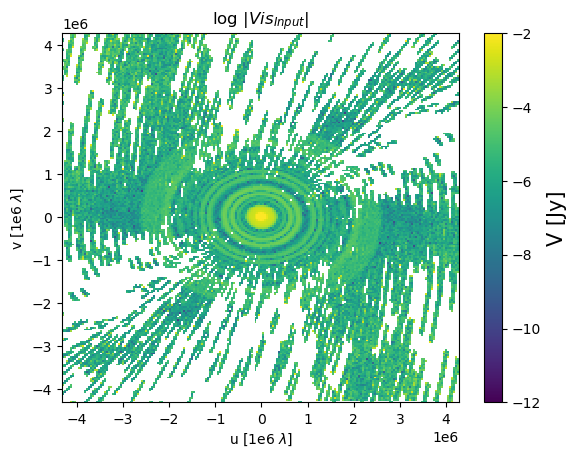

In [50]:
Nx, Ny = N, N

u_shifted, v_shifted = np.fft.fftshift(u_gridded.reshape(Nx, Ny)), np.fft.fftshift(v_gridded.reshape(Nx, Ny))
vis_shifted = np.fft.fftshift(vis_gridded.reshape(Nx, Ny))

plt.pcolormesh(v_shifted,
               u_shifted,
               np.log(np.abs(vis_shifted)),
               cmap="viridis", vmin=-12, vmax=-2)
plt.xlabel(r'u [1e6 $\lambda$]')
plt.ylabel(r'v [1e6 $\lambda$]')
plt.title(r'log |$Vis_{Input}$|')
cmap = plt.colorbar()
cmap.set_label(r'V [Jy]', size=15)

In [58]:
# Let's review the gridded visibilities first.

from frank.utilities import UVDataBinner

baselines = np.hypot(u_gridded, v_gridded)         
grid = np.logspace(np.log10(min(baselines.min(), baselines[0])),
                           np.log10(max(baselines.max(), baselines[-1])),
                           10**4)

cs, ms = ['#a4a4a4', 'k'], ['.', 'x']
bin_widths=[1e4, 1e5]

binned_vis1 = UVDataBinner(baselines, vis_gridded, weights_gridded, bin_widths[0])
logx1 = np.log10(binned_vis.uv)
logy1 = np.log10(np.abs(binned_vis.V))

binned_vis2 = UVDataBinner(baselines, vis_gridded, weights_gridded, bin_widths[1])
logx2 = np.log10(binned_vis2.uv)
logy2 = np.log10(np.abs(binned_vis2.V))

/var/folders/ng/vs__trg57hl3mtgq5kgkzj4h0000gn/T/ipykernel_10233/1966802615.py:6: RuntimeWarning: divide by zero encountered in log10
  grid = np.logspace(np.log10(min(baselines.min(), baselines[0])),
/var/folders/ng/vs__trg57hl3mtgq5kgkzj4h0000gn/T/ipykernel_10233/1966802615.py:14: RuntimeWarning: divide by zero encountered in log10
  logx1 = np.log10(binned_vis.uv)
/var/folders/ng/vs__trg57hl3mtgq5kgkzj4h0000gn/T/ipykernel_10233/1966802615.py:15: RuntimeWarning: divide by zero encountered in log10
  logy1 = np.log10(np.abs(binned_vis.V))


<Figure size 640x480 with 0 Axes>

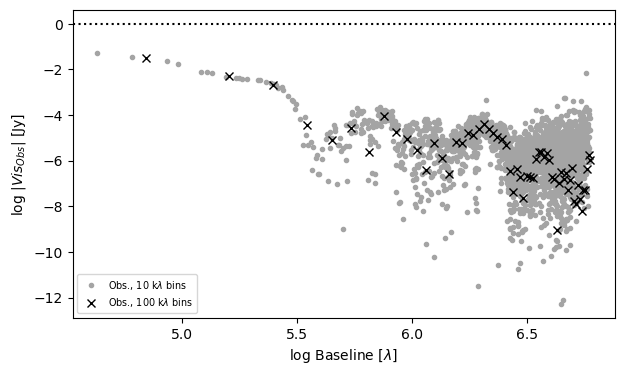

In [57]:
plt.clf()
plt.figure(figsize=(7, 4))
plt.plot(logx1, logy1, c=cs[0], marker=ms[0], ls='None', label=r'Obs., {:.0f} k$\lambda$ bins'.format(bin_widths[0]/1e3))
plt.plot(logx2, logy2, c=cs[1], marker=ms[1], ls='None', label=r'Obs., {:.0f} k$\lambda$ bins'.format(bin_widths[1]/1e3))

plt.axhline(0, c='black', ls=':')
plt.title("", size = 10)    
plt.xlabel(r'log Baseline [$\lambda$]', size = 10)
plt.ylabel(r'log $|Vis_{Obs}|$ [Jy]', size = 10)
plt.legend(loc = 'best', fontsize = 'x-small')
plt.show()